In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Cleaned_Restaurant_Dataset.csv')

# **LEVEL 3**

# **TASK 1 (Task: Restaurant Reviews)**

**1.Analyze the text reviews to identify the most common positive and negative keywords.**

In [ ]:
from wordcloud import WordCloud

In [ ]:
# Separate the Rating text into Positive and Negative groups
# Positive: Excellent, Very Good, Good
# Negative: Average, Poor
positive_text = " ".join(df[df['Rating text'].str.contains('Excellent|Good|Very Good', na=False)]['Rating text'])
negative_text = " ".join(df[df['Rating text'].str.contains('Average|Poor', na=False)]['Rating text'])

In [ ]:
#. Create WordClouds
pos_wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
neg_wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

## **Visualization**

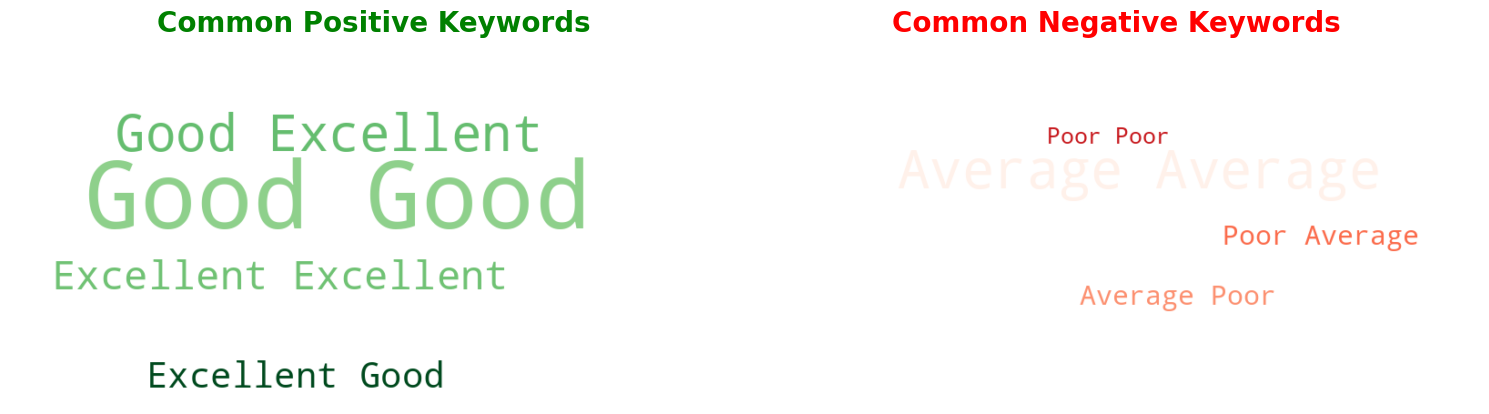

In [ ]:
plt.figure(figsize=(15, 10))

# Positive WordCloud
plt.subplot(1, 2, 1)
plt.imshow(pos_wordcloud, interpolation='bilinear')
plt.title('Common Positive Keywords', fontsize=20, fontweight='bold', color='green')
plt.axis('off')

# Negative WordCloud
plt.subplot(1, 2, 2)
plt.imshow(neg_wordcloud, interpolation='bilinear')
plt.title('Common Negative Keywords', fontsize=20, fontweight='bold', color='red')
plt.axis('off')

plt.tight_layout()
plt.show()

**2. Calculate the average length of reviews and explore if there is a relationship between review length and rating**

In [ ]:
#. Calculate the length of the 'Rating text'
# We treat 'Rating text' as the review content for this analysis
df['Review Length'] = df['Rating text'].astype(str).apply(len)

In [ ]:
#. Calculate Average Length
average_review_length = df['Review Length'].mean()
print(f"Average length of Rating Text: {average_review_length:.2f} characters")

Average length of Rating Text: 7.02 characters


In [ ]:
#. Analyze Relationship (Correlation)
correlation = df['Review Length'].corr(df['Aggregate rating'])
print(f"Correlation between Review Length and Aggregate Rating: {correlation:.2f}")

Correlation between Review Length and Aggregate Rating: -0.48


/tmp/ipykernel_9119/811923952.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Review Length', y='Aggregate rating', data=df, palette='coolwarm')


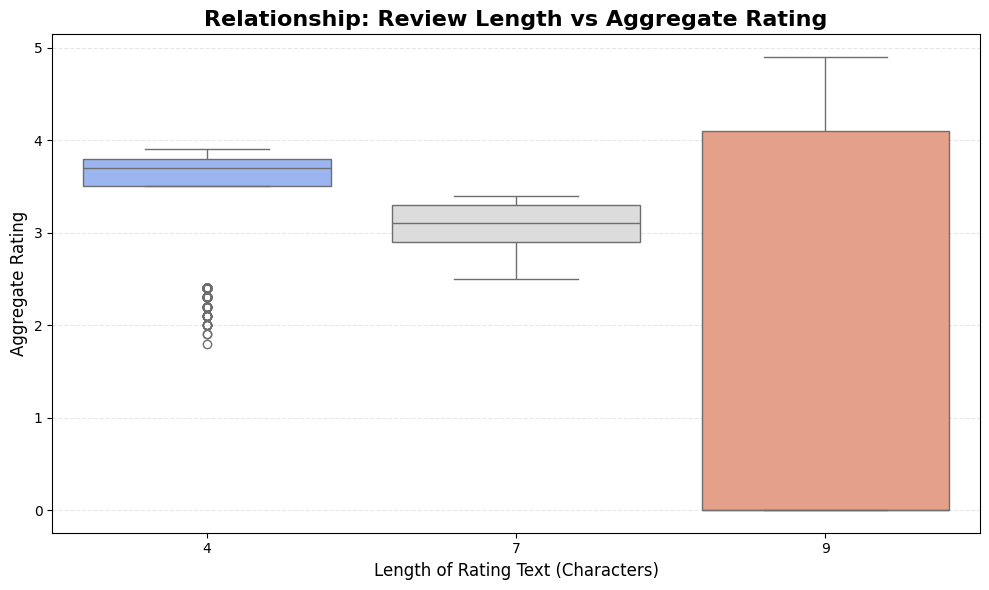

In [ ]:
#. Visualization: Box Plot
# A Box Plot is better here because Review Length has discrete values
plt.figure(figsize=(10, 6))
sns.boxplot(x='Review Length', y='Aggregate rating', data=df, palette='coolwarm')

plt.title('Relationship: Review Length vs Aggregate Rating', fontsize=16, fontweight='bold')
plt.xlabel('Length of Rating Text (Characters)', fontsize=12)
plt.ylabel('Aggregate Rating', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# **TASK 2 (Task: Votes Analysis)**

**1.Identify the restaurants with the highest and lowest number of votes**

In [ ]:
#. Find the restaurant with the HIGHEST votes
highest_voted = df.sort_values(by='Votes', ascending=False).iloc[0]

In [ ]:
# Find the restaurants with the LOWEST votes
# Since many have 0, we'll find the minimum value first
min_votes = df['Votes'].min()
num_lowest = len(df[df['Votes'] == min_votes])

In [ ]:
print(f"Highest Votes: {highest_voted['Restaurant Name']} with {highest_voted['Votes']} votes.")
print(f"Lowest Votes: {min_votes} votes (Found in {num_lowest} restaurants).")

Highest Votes: Toit with 10934 votes.
Lowest Votes: 0 votes (Found in 1094 restaurants).


**Visualization: Top 10 Most Voted Restaurants**

/tmp/ipykernel_9119/410642268.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_voted, x='Votes', y='Restaurant Name', palette='plasma')


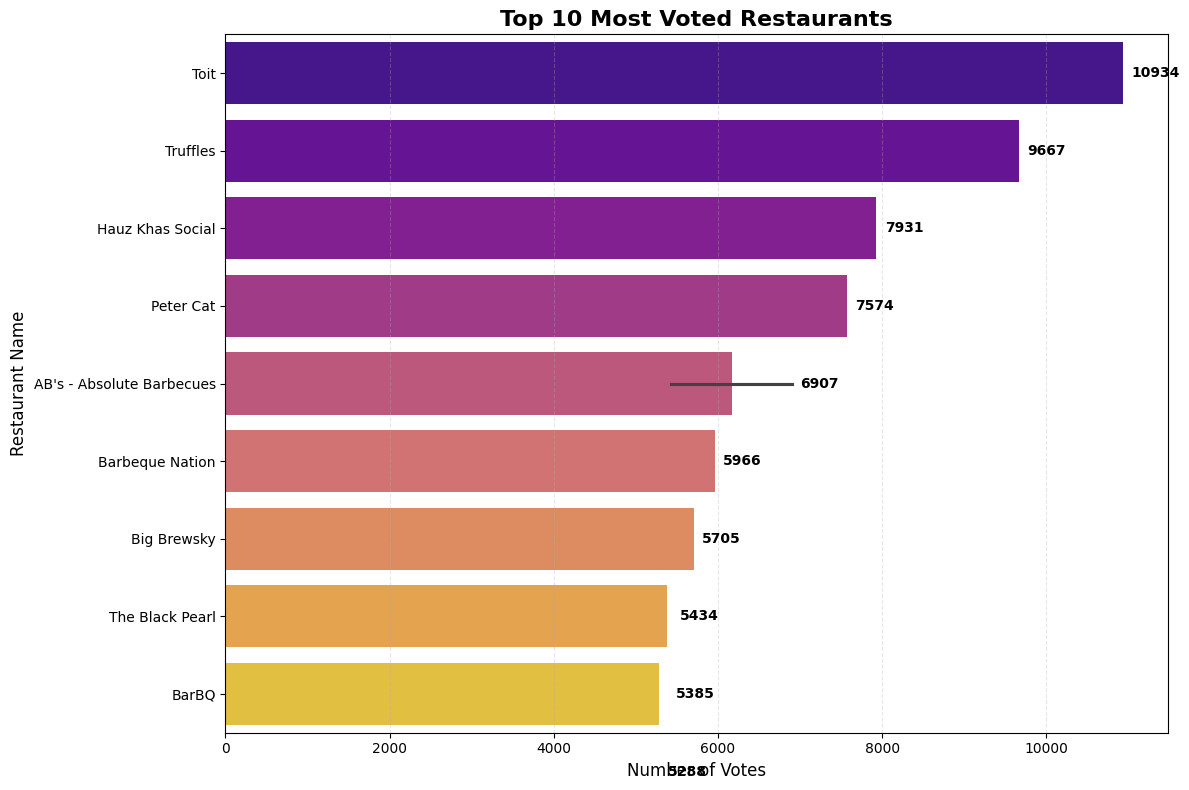

In [ ]:
top_10_voted = df.sort_values(by='Votes', ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_10_voted, x='Votes', y='Restaurant Name', palette='plasma')

# Adding labels for clarity
for i, v in enumerate(top_10_voted['Votes']):
    plt.text(v + 100, i, str(v), va='center', fontweight='bold')

plt.title('Top 10 Most Voted Restaurants', fontsize=16, fontweight='bold')
plt.xlabel('Number of Votes', fontsize=12)
plt.ylabel('Restaurant Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**2. Analyze if there is a correlation between the number of votes and the rating of a restaurant.**

In [ ]:
#. Calculate the Pearson Correlation
correlation = df['Votes'].corr(df['Aggregate rating'])
print(f"Correlation between Votes and Rating: {correlation:.4f}")

Correlation between Votes and Rating: 0.3137


**Visualization: Scatter Plot with Regression Line**

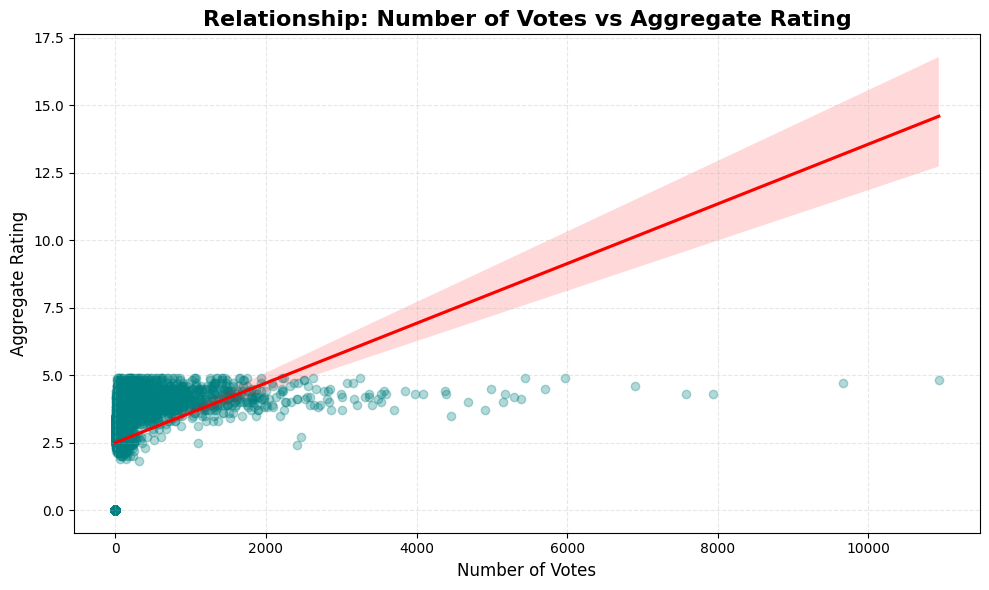

In [ ]:
plt.figure(figsize=(10, 6))
# regplot shows individual points and the trend line
sns.regplot(data=df, x='Votes', y='Aggregate rating',
            scatter_kws={'alpha': 0.3, 'color': 'teal'},
            line_kws={'color': 'red'})

plt.title('Relationship: Number of Votes vs Aggregate Rating', fontsize=16, fontweight='bold')
plt.xlabel('Number of Votes', fontsize=12)
plt.ylabel('Aggregate Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# **Task 3 (Price Range vs. Online Delivery and Table Booking)**

**1. Analyze if there is a relationship between the price range and the availability of online delivery and table booking**

In [ ]:
#. Cross-tabulate Price Range with Online Delivery and Table Booking
# We normalize by index to get percentages (0-100)
delivery_pct = pd.crosstab(df['Price range'], df['Has Online delivery'], normalize='index') * 100
booking_pct = pd.crosstab(df['Price range'], df['Has Table booking'], normalize='index') * 100

**Visualization: Side-by-Side Stacked Bar Charts**

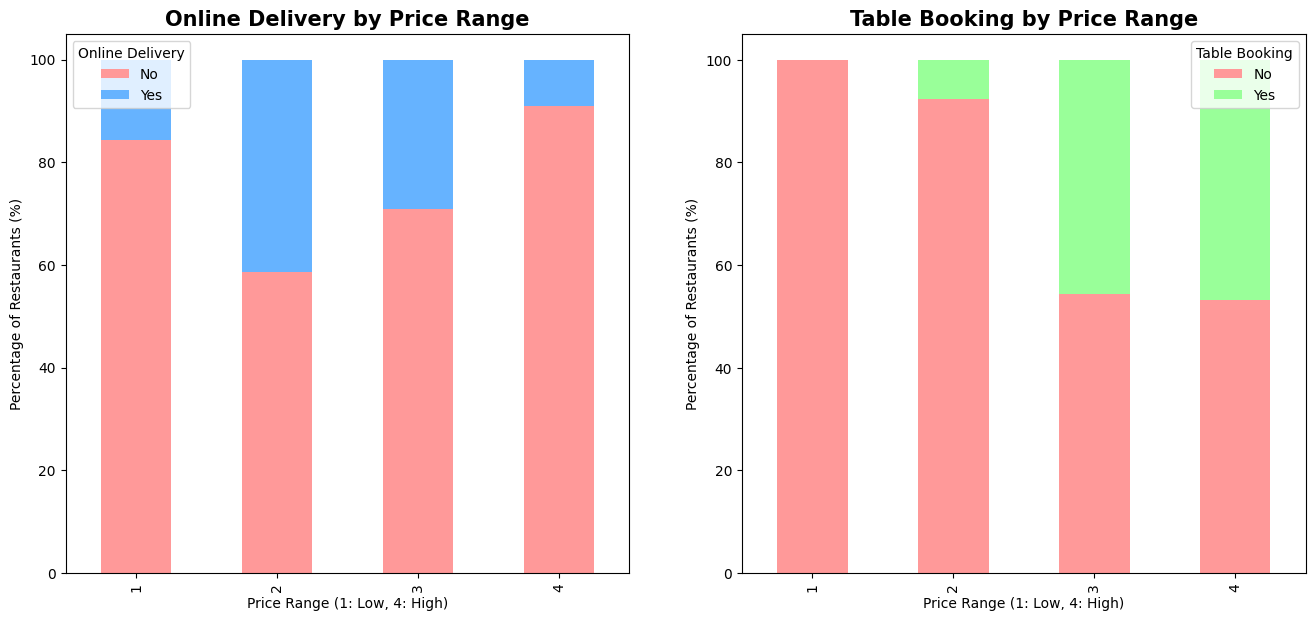

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Online Delivery vs Price Range
delivery_pct.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax[0])
ax[0].set_title('Online Delivery by Price Range', fontsize=15, fontweight='bold')
ax[0].set_ylabel('Percentage of Restaurants (%)')
ax[0].set_xlabel('Price Range (1: Low, 4: High)')
ax[0].legend(title='Online Delivery', labels=['No', 'Yes'])

# Plot 2: Table Booking vs Price Range
booking_pct.plot(kind='bar', stacked=True, color=['#ff9999','#99ff99'], ax=ax[1])
ax[1].set_title('Table Booking by Price Range', fontsize=15, fontweight='bold')
ax[1].set_ylabel('Percentage of Restaurants (%)')
ax[1].set_xlabel('Price Range (1: Low, 4: High)')
ax[1].legend(title='Table Booking', labels=['No', 'Yes'])


**2. Determine if higher-priced restaurants are more likely to offer these services.**

In [ ]:
#. Convert 'Yes'/'No' to 1/0 to calculate the "Likelihood" (Mean)
df['Has_Delivery_Bool'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})
df['Has_Booking_Bool'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})

In [ ]:
#. Calculate likelihood per price range
likelihood_study = df.groupby('Price range')[['Has_Delivery_Bool', 'Has_Booking_Bool']].mean() * 100
likelihood_study.columns = ['Online Delivery Likelihood (%)', 'Table Booking Likelihood (%)']

print("--- Service Likelihood by Price Tier ---")
print(likelihood_study.round(2))

--- Service Likelihood by Price Tier ---
             Online Delivery Likelihood (%)  Table Booking Likelihood (%)
Price range                                                              
1                                     15.77                          0.02
2                                     41.31                          7.68
3                                     29.19                         45.74
4                                      9.04                         46.76
